In [9]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import os, sys
from pathlib import Path
from glob import glob
from tqdm.auto import tqdm

sys.path.append(".")

## Processing UniPen dataset

In [8]:
UNIPEN_DIR = Path("./data/unipen/CDROM/train_r01_v07")

In [11]:

def _extract_char(raw: str) -> str | None:
    """
    Parse the character label from the quoted string in a .SEGMENT line.
    Returns a single Python character, or None if unrecognised.
    """
    # Strip surrounding quotes (single or double)
    s = raw.strip("\"'")

    # Unescape UNIPEN backslash sequences
    if s == "\\\\":     # file contains "\\" → backslash
        return "\\"
    if s == '\\"':      # file contains "\"" → double-quote
        return '"'

    # Keep only single-character labels; multi-char labels are special tokens
    # like "SPC", "DEL", etc. which we cannot map to a glyph.
    if len(s) == 1:
        return s

    return None

# read unipen data/*.dat file
def collect_segments(file_path: Path):
    inc_file_path = None
    segments = []
    with open(file_path, encoding="latin-1", errors="replace") as fh:
        for raw in fh:
            line = raw.strip()
            
            # read meta file description
            if line.startswith(".INCLUDE "):
                inc_rel  = line[9:].strip()
                inc_path = UNIPEN_DIR / "include" / inc_rel
                inc_file_path = inc_path

            # read segment description
            if line.startswith(".SEGMENT CHARACTER "):
                # Format: .SEGMENT CHARACTER <idx> <quality> "<char>"
                rest  = line[len(".SEGMENT CHARACTER "):].strip()
                parts = rest.split(None, 2)   # at most 3 tokens
                if len(parts) < 3:
                    continue

                idx_str = parts[0] # "0", "4-5", "101"
                char_raw = parts[2].strip()  # '"b"', '"\\"', '"\""'

                char = _extract_char(char_raw)
                if char is None:
                    continue

                try:
                    if "-" in idx_str:
                        s, e = idx_str.split("-", 1)
                        start, end = int(s), int(e)
                    else:
                        start = end = int(idx_str)
                except ValueError:
                    continue

                if start > end or start < 0:
                    continue

                segments.append((start, end, char))
            

    return (
        inc_file_path,
        segments
    )

# let's read the corresponding strokes list
def collect_strokes(inc_file_path: Path):
    in_stroke = False
    strokes = []
    current = []
    with open(inc_file_path, encoding="latin-1", errors="replace") as fh:
        for raw in fh:
            line = raw.strip()

            if line == ".PEN_DOWN":
                in_stroke = True
                current = []

            elif line == ".PEN_UP":
                if current:
                    strokes.append(current)
                in_stroke = False 
                current = []  # reset current stroke
            
            elif in_stroke and line and not line.startswith("."):
                # has a coordinate
                parts = line.split()
                current.append([float(parts[0]), float(parts[1])])
    return strokes


# let's run a loop and collect all necessary strokes and segments
data = []
for dirname in ['1a', '1b', '1c', '1d', '2']:
    flist = glob(f"data/{dirname}/**/*.dat", root_dir=UNIPEN_DIR, recursive=True)
    for f in tqdm(flist, desc=f"Processing folder {dirname}"):
        inc_file_path, segments = collect_segments(UNIPEN_DIR / f)
        strokes = collect_strokes(inc_file_path)
        for seg in segments:
            seg_start, seg_end, char = seg
            char_strokes = strokes[seg_start:(seg_end+1)]

            # put the strokes in the data
            data.append({
                "char": char,
                "strokes": char_strokes,
                "source": inc_file_path,
                "source_idx_start": seg_start,
                "source_idx_end": seg_end
            })

Processing folder 1a:   0%|          | 0/634 [00:00<?, ?it/s]

Processing folder 1b:   0%|          | 0/1423 [00:00<?, ?it/s]

Processing folder 1c:   0%|          | 0/2145 [00:00<?, ?it/s]

Processing folder 1d:   0%|          | 0/1222 [00:00<?, ?it/s]

Processing folder 2:   0%|          | 0/2735 [00:00<?, ?it/s]

In [13]:
# Some utility function for plotting
def plot_strokes(strokes: list, ax=None, title='', color='black'):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    for stroke in strokes:
        if len(stroke) < 2: continue
        xs = [p[0] for p in stroke]
        ys = [p[1] for p in stroke]  # flip y for standard orientation
        ax.plot(xs, ys, color=color, linewidth=2, solid_capstyle='round')
    ax.set_aspect('equal'); ax.axis('off')
    if title: ax.set_title(title, fontsize=10)
    return ax

<Axes: title={'center': '2'}>

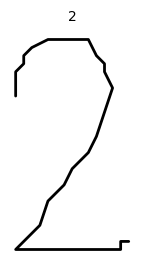

In [21]:
# verify if the obtained strokes look fine
index = 777
plot_strokes(data[index]['strokes'], title = data[index]['char'])

In [23]:
# let's look at the counters of chars
char_counts = {}
for index in range(len(data)):
    char = data[index]['char']
    if char in char_counts:
        char_counts[char] += 1
    else:
        char_counts[char] = 1

char_counts

{'1': 3492,
 '5': 3032,
 '6': 3034,
 '2': 3304,
 '9': 3088,
 '3': 3176,
 '7': 3088,
 '8': 3112,
 '0': 3286,
 '4': 3248,
 'C': 2042,
 'D': 1950,
 'F': 1732,
 'J': 1532,
 'M': 1876,
 'O': 3214,
 'P': 2014,
 'V': 1582,
 'W': 1726,
 'Y': 1772,
 'Z': 1684,
 'A': 2824,
 'E': 3372,
 'N': 2142,
 'Q': 1634,
 'R': 2368,
 'T': 2518,
 'U': 2202,
 'X': 1468,
 'B': 1868,
 'G': 1742,
 'H': 1912,
 'I': 2912,
 'S': 2572,
 'K': 1754,
 'L': 2190,
 'a': 6844,
 'b': 2504,
 'c': 3168,
 'd': 3934,
 'g': 3170,
 'j': 1888,
 'k': 2600,
 'l': 5154,
 's': 5444,
 'u': 3992,
 'v': 1958,
 'w': 2572,
 'z': 2058,
 'e': 9812,
 'f': 2802,
 'i': 6438,
 'm': 3086,
 'n': 6362,
 'o': 6874,
 't': 6010,
 'h': 4164,
 'q': 2250,
 'x': 1742,
 'y': 2646,
 'r': 5602,
 'p': 3354,
 '.': 2532,
 '-': 1728,
 ';': 1182,
 ':': 1326,
 ',': 1376,
 '\\': 1760,
 '$': 906,
 '(': 1582,
 '*': 1080,
 '<': 924,
 '>': 972,
 '?': 904,
 '@': 566,
 '[': 646,
 '`': 288,
 '}': 576,
 '%': 858,
 '&': 566,
 ')': 1870,
 '+': 1152,
 '/': 1324,
 '=': 1036,
 

In [24]:
# store the data as pickle file in processed
import pickle

with open("./data/processed/unipen_parsed.pkl", "wb") as f:
    pickle.dump(data, f)
    f.close()

## Load Data and Perform Model Training